# Chapter 6 - Probabilities of Default (PD): Discrete-Time Hazard Models

We will start out notebook by loading all datasets that might be useful for us.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import feature_selection
from sklearn import pipeline
from sklearn import tree
from optbinning import BinningProcess
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
warnings.simplefilter(action='ignore', category=FutureWarning)

In [29]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

### Default Events

A probability of default (PD) describes the likelihood of a default event. Default are usually indicated with a default indicator.

$$
D_{it} = 
\begin{cases} 
1 & \text{borrower } i \text{ defaults at time } t \\
0 & \text{otherwise} 
\end{cases}
$$

Let's assume that a default is represented as $d$ when realized.

### Conditional and Unconditional Default

When looking at multiple period PD, usually the probability of default of time t=2, for example, is dependent on a nondefault on time t=0.  However, in multiyears evaluations, as in done in the context of compuyting expected present value or loss values for financial instruments. The unconditional probability of default is often used to measure the likelihood of default from the perspective of the loan's origination. The conditional probability of default measures the likelihood of default conditional on survival and is often used to measure the risk after origination. They are identical in the first period (as there is still no condition).

Assuming every borrower has the same contional $PD_{t-1}$ at any period $t-1, t$, we can omit the borrower index i. The unconditional PD ($UPD_{t_1,t_2}$) is given as:

$$UPD_{t_1,t_2} = S(t_1) - S(t_2)$$
$$= \prod_{t=1}^{t_1} (1-PD_{t-1,t}) - \prod_{t=1}^{t_2} (1-PD_{t-1,t})$$
$$= \prod_{t=1}^{t_1} (1-PD_{t-1,t}) - \left( \prod_{t=1}^{t_1} (1-PD_{t-1,t}) \prod_{t=t_1}^{t_2} (1-PD_{t-1,t}) \right)$$
$$= \prod_{t=1}^{t_1} (1-PD_{t-1,t}) \left( 1 - \prod_{t=t_1}^{t_2} (1-PD_{t-1,t}) \right)$$
$$= S(t_1)PD_{t_1,t_2}$$

$S(t)$ is the cumulative survival probability to time $t$ (i.e., no default by time $t$).



### Real-World vs Risk-Neutral

Default probabilities are called real-world if they are modeled for real-world realization. For marketable exposures, risk-neutral probabilities of default may be derived from observed market prices. Although very popular in finance literature, it's limited to a small fraction of total credit exposures. Moreover, risk-neutral probabilities can be quite different from real-world probability due to the premiums for risk aversion and are therefore of only limited value for risk management.

### Basel Requirements

In order to determine regulatory capital requirements, banks often assign rating classes to borrowers and then compute default probabilities for these rating classes. For non-retail exposure, the default rating should exclusively reflect the risk of obligator default. There should be at least seven ratings for nondefaulted obligors and one rating ofr the defaulters. 

As for retail exposure, credit rating needs to reflect both obligor and trasaction risk. Hence, credit product characteristics and collateralization also need to be taken into account. Ratings should be as homogeneous as possible in terms of default risk.

To calculate the PD, at least five years of historical data should be used, although not all data should recieve equal weight (the weight should be used according to relevance). The PD of a particular rating can then be estimated as the long-run average of the one-year default rates.

### Parameter Estimation

It is common to assume that default events are driven by an unobservable data-generating process (DGP). Many different models have been proposed in the literature to understand its key components. 

#### Merton Model for Coporate Borrowers

In this model, default occurs if the market value of the assets (or the return) falls below the market value of the outstading debt. The asset value is often assumed to follow a lognormal distribution, and the asset return a normal distribution. The standardized asset return $A_{it}$ of borrower $i$ in time $t$ can be modeled as a latent process. A default event occurs if the asset return $A_{it}$ falls below a threshould $\gamma_{it}$. The probability of default then becomes:

$$PD_{it} = P(D_{it}=1) = P(A_{it} < \gamma_{it}) = \Phi(\gamma_{it})$$

With $\Phi$ the cumulative density function of the standard normal distribution. This model results in a probit model with the linear predictor $\gamma_{it}$.



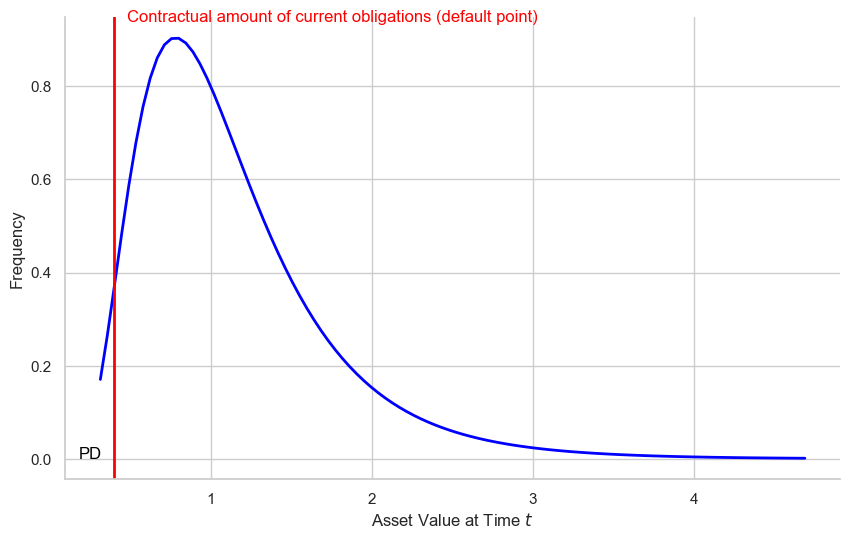

In [30]:
sns.set_theme(style="whitegrid")
s = 0.5  # Shape parameter
loc = 0  # Location parameter
scale = 1  # Scale parameter
x = np.linspace(lognorm.ppf(0.01, s, loc=loc, scale=scale),
                lognorm.ppf(0.999, s, loc=loc, scale=scale), 100)

pdf_values = lognorm.pdf(x, s, loc=loc, scale=scale)
plt.figure(figsize=(10, 6))
ax = sns.lineplot(x=x, y=pdf_values, color='blue', linewidth=2)

default_point = s - 0.1
plt.axvline(x=default_point, color='red', linestyle='-', linewidth=2)

plt.text(default_point*1.2, ax.get_ylim()[1], 'Contractual amount of current obligations (default point)', 
         color='red', ha='left', va='center')
plt.text(default_point*0.8, ax.get_ylim()[1]*0.01, 'PD', 
         color='black', ha='right', va='center')

plt.xlabel('Asset Value at Time $t$')
plt.ylabel('Frequency')

sns.despine()
plt.show()

### Discrete-Time Hazard Models

Discrete-time hazard models are estimated by maximizing the product over the observational likelihoods. This implies that discrete-time hazard models treat the observations as conditionally independent. For loan exposures, every loan is observed in periodic intervals to either default, payoff, or end of the observation period.

In [31]:
mortgage_ = mortgage[['id', 'orig_time', 'time', 'default_time', 'payoff_time', 'FICO_orig_time', 'LTV_orig_time', 'LTV_time', 'gdp_time', 'uer_time', 'hpi_time']]
mortgage_[(mortgage_['id'].isin([46,47,56]))&(mortgage_['time'].isin([25,26,27,28,29,58,59,60]))]

,id,orig_time,time,default_time,payoff_time,FICO_orig_time,LTV_orig_time,LTV_time,gdp_time,uer_time,hpi_time
354,46,19,25,0,0,581,80.0,66.814884,2.899137,4.7,226.29
355,46,19,26,0,0,581,80.0,67.039387,2.151365,4.7,225.10
356,46,19,27,0,0,581,80.0,67.591349,2.361722,4.4,222.39
357,46,19,28,0,0,581,80.0,68.291913,1.229172,4.6,219.67
358,46,19,29,1,0,581,80.0,68.875167,1.692969,4.5,217.37
359,47,19,25,0,0,600,80.0,66.793811,2.899137,4.7,226.29
360,47,19,26,0,0,600,80.0,66.960918,2.151365,4.7,225.10
361,47,19,27,0,1,600,80.0,67.585347,2.361722,4.4,222.39
390,56,-15,25,0,0,664,52.5,17.118471,2.899137,4.7,226.29
391,56,-15,26,0,0,664,52.5,17.169595,2.151365,4.7,225.10


The FICO mortgage score is a credit score with values between 300 and 850. LTV ius the ratio of outstdaing loan amount to the collateral value, and banks traditionally extend loans in the region of 80 percent. The unemployment rate is time-varying and has the same value for all loan in a given observation period. Loan 46 defaults in period time = 29, which is indicated by the binary variable default_time. Loan 56 survives until the end of our observation period (time=60), and we will later refer to this as a right-censored observation.

Discrete-time hazard regression models establish a link between the probability of the binary default variable taking on a particular value (e.g, default) and the observable information through nonlinear link functions $F: PD(D_{it}=1) = F(lp{it-1})$. The models are generally formulated in terms of expectation due to the binary character of the dependent variable. Furthermore, $lp_{it-1}$ is a linear predictor formulated in terms of $lp_{it-1}$, that is a linear combination of observable information and the parameters that are estimated.
PD is time-varying and explanatory variables need to be known at the beginning of the observation period to enable the models to privide out-of-time econometric forecasts. Otherwise we won't be able to predict future PD.

### Linear Model

Generally estimated with an OLS technique. The model equation is:

$$D_{it} = \beta'x_{it-1} + e_{it}$$

with a vector of appropriate covariates $x_{it-1}$, the corresponding sensitivies $\beta$ abd $e_{it}$, which is normally distributed with mean zero and standard deviation $\sigma$. The model can be estimated as follows:

In [32]:
y = mortgage_['default_time']
X = mortgage_[['FICO_orig_time', 'LTV_orig_time', 'gdp_time']]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           default_time   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1746.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:25:17   Log-Likelihood:             2.8334e+05
No. Observations:              622489   AIC:                        -5.667e+05
Df Residuals:                  622485   BIC:                        -5.666e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0796      0.003     30.

The linear model is not popular for estimating borrower/loan-level default probabilities, as the predicted probabilities of default are not constrained within the range of the defined default probabilities of 0 and 1. In a simple linear regression, we can obtain values below 0 or above 1, which are unreasonable and often cause problems in a follow-up application such as the computation of regulatory capital or loan pricing.

The low R-squared is common for binary models and a reflection of the data-generating process. The realization of default events is based on a random binary variable and the default probability as event likelihood. The random experiment explains the low fit, and better results are achieved when default rates (rather than default events) are modeled.

### Nonlinear Models: Probit, Logit and Cloglog Models

##### Specifying the Link Function

In order to constrain the dependent variable to the defined range of zero to one, nonlinear link functions can be applied. The nonlinear link functions are generally inverse cumulative distribution functions of well-known distributions. The functions used in the book are probit, logit and cloglog (complementary log-log). Which are bounded between zero and one.

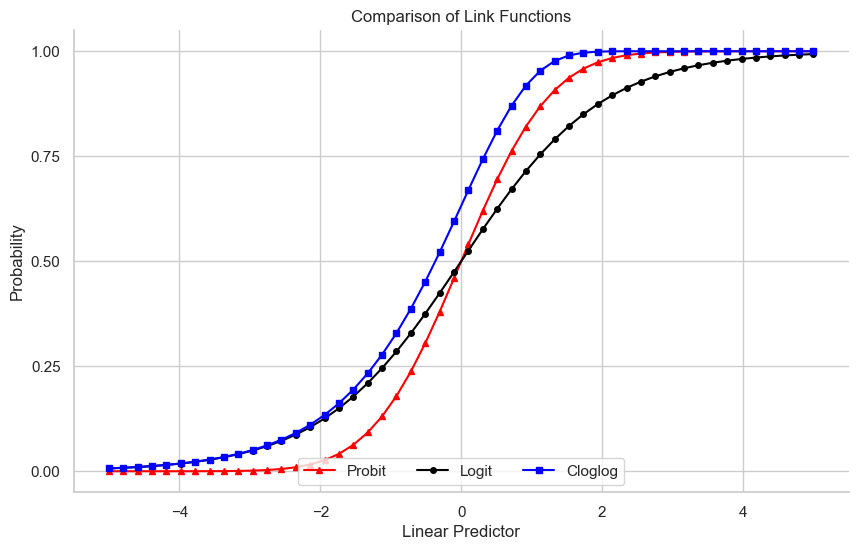

In [33]:
from scipy.stats import norm

sns.set_theme(style="whitegrid")
x = np.linspace(-5, 5, 50)

def logit_func(x):
    return 1 / (1 + np.exp(-x))

def probit_func(x):
    return norm.cdf(x)

def cloglog_func(x):
    return 1 - np.exp(-np.exp(x))

y_logit = logit_func(x)
y_probit = probit_func(x)
y_cloglog = cloglog_func(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y_probit, label='Probit', color='red', marker='^', markersize=4, linestyle='-')
plt.plot(x, y_logit, label='Logit', color='black', marker='o', markersize=4, linestyle='-')
plt.plot(x, y_cloglog, label='Cloglog', color='blue', marker='s', markersize=4, linestyle='-')
plt.xlabel('Linear Predictor')
plt.ylabel('Probability')
plt.title('Comparison of Link Functions')
plt.yticks(np.arange(0, 1.01, 0.25))
plt.legend(loc='lower center', ncol=3)
sns.despine()
plt.show()

The shapes of the three link functions are comparable, yet distinct. Different link functions result in different parameter estimates but the predicted values, are comparable.

#### Probit Model

Logit link function has useful properties if the resulting mean PDs have to be calibrated to a different level. The probit link function is particulary useful for estimating parameters that are in line with IRB models under the Basel regulations, as these assume the probit link.

The probit model equation is:

$$PD(D_{it} = 1|X_{it-1})=\Phi(\beta'x_{it-1})$$

With $\Phi(.)$ the cumulative density function of the standard normal distribution, $\beta$ a vector of sensitivity and $x_{it-1}$ a vector of time-lagged risk factors. The following code estimates a logit model:

In [34]:
y = mortgage_['default_time']
X = mortgage_[['FICO_orig_time', 'LTV_orig_time', 'gdp_time']]
X = sm.add_constant(X)
model = sm.Probit(y, X).fit()
mortgage_.loc[:, 'PD_time'] = model.predict(X)
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.110580
         Iterations 7


C:\Users\guilh\AppData\Local\Temp\ipykernel_8812\904367591.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortgage_.loc[:, 'PD_time'] = model.predict(X)


                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622489
Model:                         Probit   Df Residuals:                   622485
Method:                           MLE   Df Model:                            3
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                 0.03440
Time:                        21:25:19   Log-Likelihood:                -68835.
converged:                       True   LL-Null:                       -71287.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.0911      0.046    -23.775      0.000      -1.181      -1.001
FICO_orig_time    -0.0021   4.91e-05    -42.520      0.000      -0.002      -0.002
LTV_orig_time      0.0074      0.000

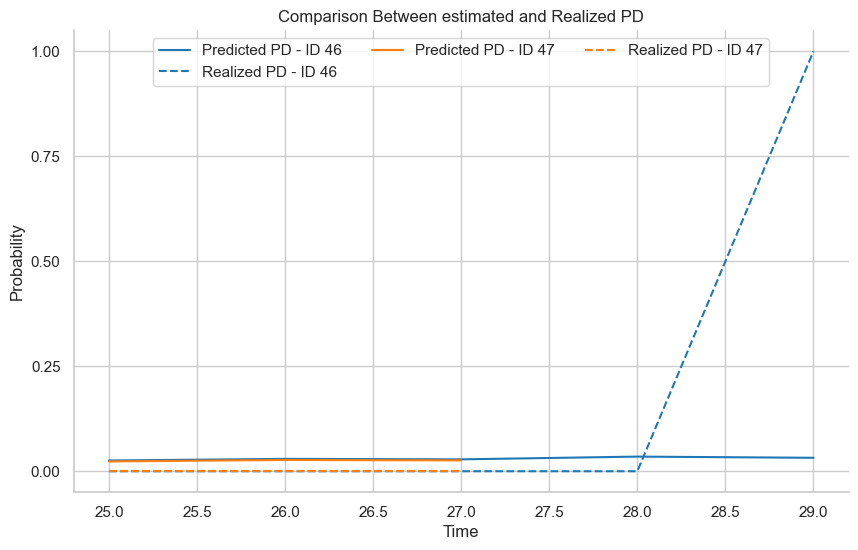

In [35]:
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 
ids_to_plot = mortgage_[(mortgage_['id'].isin([46,47]))]['id'].unique()
for i, id_ in enumerate(ids_to_plot):
    df = mortgage_[(mortgage_['id']==id_)]
    plt.plot(df['time'], df['PD_time'], label=f'Predicted PD - ID {id_}', color=colors[i], linestyle='-')
    plt.plot(df['time'], df['default_time'], label=f'Realized PD - ID {id_}', color=colors[i], linestyle='--')

plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Comparison Between estimated and Realized PD')
plt.yticks(np.arange(0, 1.01, 0.25))
plt.legend(loc='upper center', ncol=3)
sns.despine()
plt.show()

#### Calibration of Probit Models

An important consideration in estimating default probabilities is their calibration to the default rates. It's important to recall the Default Rate is a backward-looking measurement. It is the actual percentage of loans in a portfolio that defaulted during a specific historical period while the Probability of Default is a forward-looking estimate. It represents the likelihood that a specific borrower or a group of borrowers will fail to meet their debt obligations over a set timeframe (usually one year) and in discrete-time hazard models by definition the mean of the estimated default probabilities matches the default rate of the estimation sample. The intercept parameter captures any baseline risk that is not attributable to the explanatory variable.

Calibration is a mandatory standard for building Basel-compliant credit risk models. Models that fail to meet calibration standards are not approved for:
- Capital allocation.
- Loan loss provisioning.
- Stress testing.
- Internal purposes like loan pricing.

The model we estimated can be written as the folowing:

$\hat{P}(D_{it} = 1 | \mathbf{X}_{it-1}) = \Phi(\hat{\beta}_0 + \hat{\beta}_1 \cdot \text{FICO\_orig\_time} + \hat{\beta}_2 \cdot \text{LTV\_time} + \hat{\beta}_3 \cdot \text{gdp\_time})$

In [36]:
def association_metrics(y_true, y_prob):
    c = roc_auc_score(y_true, y_prob)
    
    # Somers' D is calculated as 2*c - 1
    somers_d = 2 * c - 1
    
    return pd.Series({
        'Somers\' D': somers_d,
        'c (AUROC)': c
    })

means_analysis = mortgage_[['default_time', 'PD_time']].mean()
print("--- Calibration Analysis (Equivalent to PROC MEANS) ---")
print(means_analysis)
print('\n')

metrics = association_metrics(mortgage_['default_time'], mortgage_['PD_time'])
print("--- Association of Predicted Probabilities ---")
print(metrics)

--- Calibration Analysis (Equivalent to PROC MEANS) ---
default_time    0.024351
PD_time         0.024363
dtype: float64


--- Association of Predicted Probabilities ---
Somers' D    0.33576
c (AUROC)    0.66788
dtype: float64


The calibration is clear as the mean of the default event almost matches the mean of the estimated PD. The minor difference observed may be due to the estimation algorithm.

#### Logit Model

To use a logit model in python, it's pretty similar to a probit model implementation, as we will be using the same package.

In [37]:
y = mortgage_['default_time']
X = mortgage_[['FICO_orig_time', 'LTV_orig_time', 'gdp_time']]
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
mortgage_.loc[:, 'PD_time'] = model.predict(X)
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.110706
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622489
Model:                          Logit   Df Residuals:                   622485
Method:                           MLE   Df Model:                            3
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                 0.03329
Time:                        21:25:21   Log-Likelihood:                -68913.
converged:                       True   LL-Null:                       -71287.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.6761      0.106    -15.780      0.000      -1.884      -1.468
FICO_orig_time   

While using Logit, Probit and Cloglog, models often yield similar parameter signs, but their discriminatory power (ability to distinguish "good" from "bad" borrowers) can vary slightly based on the link function, so we can use AUROC and Somer's D to evaluate the models performance. 

In [38]:
means_analysis = mortgage_[['default_time', 'PD_time']].mean()
print("--- Calibration Analysis (Equivalent to PROC MEANS) ---")
print(means_analysis)
print('\n')

metrics = association_metrics(mortgage_['default_time'], mortgage_['PD_time'])
print("--- Association of Predicted Probabilities ---")
print(metrics)

--- Calibration Analysis (Equivalent to PROC MEANS) ---
default_time    0.024351
PD_time         0.024351
dtype: float64


--- Association of Predicted Probabilities ---
Somers' D    0.335673
c (AUROC)    0.667837
dtype: float64


#### Cloglog Model

The Complementary Log-Log model in python doesn't have a direct implementation as the Proobit and Logit. So we use the Generalized Linear Model class from `statsmodels` with a family linking the Cloglog.

In [39]:
y = mortgage_['default_time']
X = mortgage_[['FICO_orig_time', 'LTV_orig_time', 'gdp_time']]
X = sm.add_constant(X)
model = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.cloglog())).fit()
mortgage_.loc[:, 'PD_time'] = model.predict(X)
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           default_time   No. Observations:               622489
Model:                            GLM   Df Residuals:                   622485
Model Family:                Binomial   Df Model:                            3
Link Function:                cloglog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -68924.
Date:                Thu, 19 Feb 2026   Deviance:                   1.3785e+05
Time:                        21:25:22   Pearson chi2:                 6.01e+05
No. Iterations:                     8   Pseudo R-squ. (CS):           0.007562
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7283      0.104    -16.

In [40]:
means_analysis = mortgage_[['default_time', 'PD_time']].mean()
print("--- Calibration Analysis (Equivalent to PROC MEANS) ---")
print(means_analysis)
print('\n')

metrics = association_metrics(mortgage_['default_time'], mortgage_['PD_time'])
print("--- Association of Predicted Probabilities ---")
print(metrics)

--- Calibration Analysis (Equivalent to PROC MEANS) ---
default_time    0.024351
PD_time         0.024334
dtype: float64


--- Association of Predicted Probabilities ---
Somers' D    0.33568
c (AUROC)    0.66784
dtype: float64


### Categorical Information

#### Reference Coding
In reference coding, the respective variable is coded one if the category is given, and zero otherwise:

$$C_k = \begin{cases} 1 & \text{category } k \text{ is given} \\ 0 & \text{otherwise} \end{cases}$$

with $k = 1, \dots K - 1$. The interpretation of the parameter estimates is in terms of the linear predictor where category $k$ is given relative to the linear predictor where the reference category $K$ is given.

#### Effect Coding
In effect coding, the respective variable is coded one if the category is given and minus one if the reference category is given:

$$C_k = \begin{cases} 1 & \text{category } k \text{ is given} \\ -1 & \text{reference category } K \text{ is given} \\ 0 & \text{otherwise} \end{cases}$$

with $k = 1, \dots K - 1$.

A popular categorical variable is the origination year, also known as vitnage. The data set we are using has many vintages with different observation counts. To simplify the analysis we restrict the number of categories to vintages with sufficient observation counts by generating a new variable called orig_time2.

In [41]:
mortgage_.groupby('orig_time')['id'].count().sort_values().tail(10)

orig_time
20    29802
19    32098
18    32645
21    36172
23    38363
24    41628
22    45339
27    48184
26    54881
25    57852
Name: id, dtype: int64

To follow up the book examples, we will be taking the same orig_time as used, but as we can see above, our dataset have more viable vintages.

In [42]:
mortgage_['orig_time2'] = mortgage_['orig_time']
idx_use = mortgage_['orig_time2'].isin([20,21,22,23,24,25])
mortgage_.loc[~idx_use, 'orig_time2'] = 0

C:\Users\guilh\AppData\Local\Temp\ipykernel_8812\3638587269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortgage_['orig_time2'] = mortgage_['orig_time']


In [43]:
y = mortgage_['default_time']

# This creates dummy variables, dropping the reference category to avoid the dummy variable trap.
orig_time_dummies = pd.get_dummies(mortgage_['orig_time2'], prefix='orig', drop_first=True).astype(int)

X = pd.concat([
    mortgage_[['FICO_orig_time', 'LTV_time', 'gdp_time']], 
    orig_time_dummies
], axis=1)

X = sm.add_constant(X).fillna(0)
model = sm.Probit(y, X)
results = model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.108411
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622489
Model:                         Probit   Df Residuals:                   622479
Method:                           MLE   Df Model:                            9
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                 0.05334
Time:                        21:25:25   Log-Likelihood:                -67485.
converged:                       True   LL-Null:                       -71287.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.0015      0.035    -28.843      0.000      -1.070      -0.933
FICO_orig_time   

In [44]:
means_analysis = mortgage_[['default_time', 'PD_time']].mean()
print("--- Calibration Analysis (Equivalent to PROC MEANS) ---")
print(means_analysis)
print('\n')

metrics = association_metrics(mortgage_['default_time'], mortgage_['PD_time'])
print("--- Association of Predicted Probabilities ---")
print(metrics)

--- Calibration Analysis (Equivalent to PROC MEANS) ---
default_time    0.024351
PD_time         0.024334
dtype: float64


--- Association of Predicted Probabilities ---
Somers' D    0.33568
c (AUROC)    0.66784
dtype: float64


### Throught-the-Cycle (TTC) versus Point-in-Time(PIT)

TTC Models generally abstract from the state of the overall economy by excluding macroeconomic risk drivers. PIT models explicitly control for the state of the economy. In practice the distinction is not so easy as many risk factors are time varying and often correlated with the economy.

As in the book, let's build a TTC model based on application data (information that is observable at the moment of origination)

In [45]:
X_ttc = sm.add_constant(mortgage_[['FICO_orig_time', 'LTV_orig_time']])
model_ttc = sm.Probit(mortgage_['default_time'], X_ttc, missing='drop')
results_ttc = model_ttc.fit()
mortgage_['PD_TTC_time'] = results_ttc.predict(X_ttc)
print(results_ttc.summary())

Optimization terminated successfully.
         Current function value: 0.112725
         Iterations 7


C:\Users\guilh\AppData\Local\Temp\ipykernel_8812\3836920104.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortgage_['PD_TTC_time'] = results_ttc.predict(X_ttc)


                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622489
Model:                         Probit   Df Residuals:                   622486
Method:                           MLE   Df Model:                            2
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                 0.01566
Time:                        21:25:28   Log-Likelihood:                -70170.
converged:                       True   LL-Null:                       -71287.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.2707      0.045    -28.140      0.000      -1.359      -1.182
FICO_orig_time    -0.0019   4.83e-05    -39.584      0.000      -0.002      -0.002
LTV_orig_time      0.0071      0.000

In [48]:
auc_ttc = roc_auc_score(mortgage_['default_time'], mortgage_['PD_TTC_time'])
somers_d = 2 * auc_ttc - 1

print(f"\nAssociation Analysis:")
print(f"c (AUC): {auc_ttc:.3f}")
print(f"Somers' D: {somers_d:.3f}")


Association Analysis:
c (AUC): 0.614
Somers' D: 0.227


As for the PIT model, it's based on the FICO score at the origination and the LTV ratio at observation time (just to remember, LTV stands for Loan-to-Value ratio, being a financial metric that lenders use to asses risk and represents the portion mortgage the is being financed by the loan). We also add the GDP growth rate, unemployment rate and house price index. These are all present in the datasets available at [Credit Risk Analytics](www.creditriskanalytics.net).

In [51]:
pit_features = ['FICO_orig_time', 'LTV_time', 'gdp_time', 'uer_time', 'hpi_time']
orig_time_dummies = pd.get_dummies(mortgage_['orig_time2'], prefix='orig', drop_first=True).astype(int)

X_pit_raw = pd.concat([mortgage_[pit_features], orig_time_dummies], axis=1)
X_pit_raw = sm.add_constant(X_pit_raw)
y_raw = mortgage_['default_time']

valid_mask = y_raw.notna() & X_pit_raw.notna().all(axis=1)
X_pit_clean = X_pit_raw[valid_mask].astype(float)
y_clean = y_raw[valid_mask].astype(float)

model_pit = sm.Probit(y_clean, X_pit_clean)
results_pit = model_pit.fit()
mortgage_.loc[valid_mask, 'PD_PIT_time'] = results_pit.predict(X_pit_clean)
clean_predictions = mortgage_.loc[valid_mask, 'PD_PIT_time']

print(results_pit.summary())

Optimization terminated successfully.
         Current function value: 0.108279
         Iterations 8
                          Probit Regression Results                           
Dep. Variable:           default_time   No. Observations:               622219
Model:                         Probit   Df Residuals:                   622207
Method:                           MLE   Df Model:                           11
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                 0.05457
Time:                        21:29:22   Log-Likelihood:                -67373.
converged:                       True   LL-Null:                       -71262.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.6816      0.066    -10.289      0.000      -0.811      -0.552
FICO_orig_time   

In [53]:
auc_pit = roc_auc_score(y_clean, clean_predictions)
somers_d = 2 * auc_pit - 1

print(f"\nAssociation Analysis:")
print(f"c (AUC): {auc_pit:.3f}")
print(f"Somers' D: {somers_d:.3f}")


Association Analysis:
c (AUC): 0.714
Somers' D: 0.429


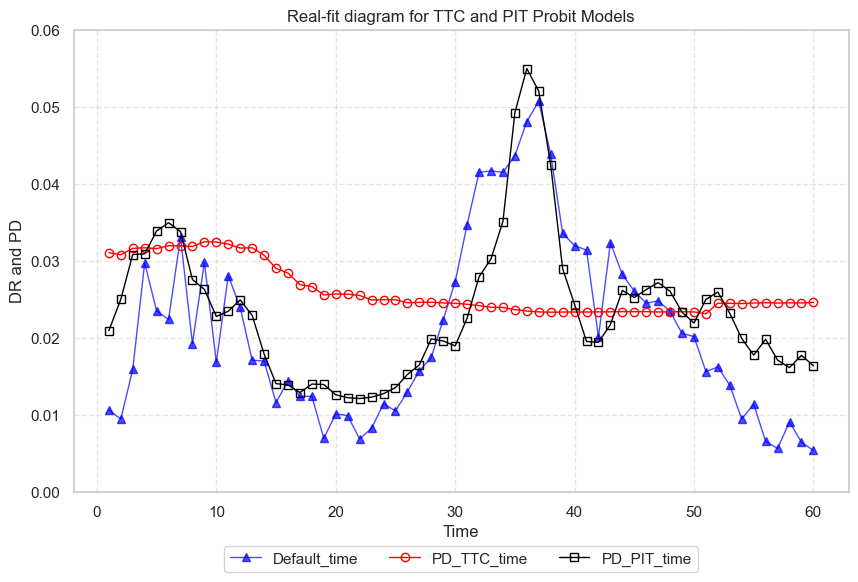

In [55]:
plot_data = mortgage_.groupby('time')[['default_time', 'PD_TTC_time', 'PD_PIT_time']].mean()

plt.figure(figsize=(10, 6))

plt.plot(plot_data.index, plot_data['default_time'], marker='^', color='blue', 
         label='Default_time', linewidth=1, alpha=0.7)

plt.plot(plot_data.index, plot_data['PD_TTC_time'], marker='o', color='red', 
         label='PD_TTC_time', linewidth=1, markerfacecolor='none')

plt.plot(plot_data.index, plot_data['PD_PIT_time'], marker='s', color='black', 
         label='PD_PIT_time', linewidth=1, markerfacecolor='none')

plt.xlabel('Time')
plt.ylabel('DR and PD')
plt.title('Real-fit diagram for TTC and PIT Probit Models')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(0, 0.06)
plt.show()

Having obtained result similar to the books, we can see that the TTC model produces default probabilities are are mostly time-invariant, the only sources for time variation are changes in the loan population, as it changes the model mean default probability. The PIT model on the other hand include time varying ratios and macro economic factors. Its mean default probability is closer to the realized default rate, as it depends on the macro economic factors, however, the use of macroeconomic variables is sometimes of concern to regulators, as their use may lead to procyclical capital requirements that may further exacerbate economic downturns, as there may be not enough provisions in an abrupt change.

To avoid such problems regulators may prohibit the use of macroeconomic indicators, mandate forward-looking, as to try to antecipate downturns based on projections or add countercyclical capital buffers. Nevertheless, PIT models are more accurate than TTC models and should be considered for measurement of economic risks, even if they may not be applied to capital charges.

### Estimation of Rating Migration Probabilities

It is common in banking to estimate rating migration probabilities (often displayed in rating migration matrices) to simplify rating analytics. As happens with default probabilities, multiyear rating migration probabilities can be computed by means of matrix multiplication.

I don't recall if in any moment the book went into details about this, but I think it's important to remember this concept so I'll add some theory here. It's really important to remember that multi-year rating migration computed via matrix multiplication rely on the property that credit ratings are typically modeled as a discrete-time markov chain process.

Why is it important? Because if we assume the Markov property, we are assuming that the future state depends only on the current state and not the sequence of events that preceded it, and this, in truth may be a problem because it assumes that a borrower who was just downgraded from A to BBB is exactly the same as a borrower who has been stable at BBB for ten years, while in reality, we observe rating momentum.

Nevertheless it's highly used and very useful. It's just important to know it's weakness. Now, let's prepare the data set by categorizing the FICO score to derive rating classes as done in the book.

In [56]:
mortgage_ = mortgage_.sort_values(by=['id', 'time'])
conditions = [
    (mortgage_['FICO_orig_time'] > 350) & (mortgage_['FICO_orig_time'] <= 500),
    (mortgage_['FICO_orig_time'] > 500) & (mortgage_['FICO_orig_time'] <= 650),
    (mortgage_['FICO_orig_time'] > 650) & (mortgage_['FICO_orig_time'] <= 850)
]
choices = [1, 2, 3]
mortgage_['rating'] = np.select(conditions, choices, default=np.nan)
mortgage_['lagid'] = mortgage_['id'].shift(1)
mortgage_['lagrating'] = mortgage_['rating'].shift(1)
mortgage_.loc[mortgage_['id'] != mortgage_['lagid'], 'lagrating'] = np.nan
mortgage_.loc[mortgage_['default_time'] == 1, 'rating'] = 4

A rating matrix tabulates the relative frequencies or estimated probabilities of mgirating from a rating at the beginning of the period to a rating including the terminal default state at the end of the period.

In [ ]:
transition_matrix = pd.crosstab(
    mortgage_['lagrating'], 
    mortgage_['rating'],
    dropna=True )

print("Rating Migration Frequency Table:")
print(transition_matrix)

transition_probabilities = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)
print("\nTransition Probability Matrix:")
print(transition_probabilities)

Rating Migration Frequency Table:
rating      1.0     2.0     3.0   4.0
lagrating                            
1.0        2731       0       0   112
2.0           5  193070      15  6978
3.0           3      50  362080  7445

Transition Probability Matrix:
rating          1.0       2.0       3.0       4.0
lagrating                                        
1.0        0.960605  0.000000  0.000000  0.039395
2.0        0.000025  0.965022  0.000075  0.034878
3.0        0.000008  0.000135  0.979712  0.020145


A default is a terminating state, ratings cannot be observed at the end of a period if the loan has defaulted at the beginning of the period. Therefore the number of rows of the rating migration matrix is one less the number of columns. In case needed for matematical aplications, usually the default row if needed is set as 0 for each rating except default, and then 1 at the default. It's also important to notice that due to probability rules, all rows must sum to 1.

Cumulative probit model
pag 176